# 02 — Data Preparation and Augmentation

**Project:** IT22638168 — MaternaLink FER track
**Pipeline position:** step 2 of 8 · see `../README.md`

## Purpose

- Apply the approved 7->3 application-state mapping (must be decided before this runs).
- Preprocess: resize, normalize, channel handling for MobileNetV2.
- Define augmentation and justify each transform.
- Create train/validation/test splits with NO leakage.
- Save processed arrays to data/processed/ with a dataset_version tag.

## Before running

Read `../../../docs/system/MOOD_STATE_SPEC.md` — it defines the label space this model targets.

> **Note:** Splits must be leakage-free. Record the dataset_version — every later run references it.

## Status

Not yet run.


> **Scope of this notebook.** This notebook characterises data-quality evidence (duplicates,
> anomalies, BlazeFace detectability) and produces **manifests** — CSV/JSON files that list which
> images belong to which cleaning tier. It does **not** delete, move, or modify anything under
> `../data/raw/`, does **not** materialise resized/normalised arrays to disk, does **not** train or
> evaluate any model, does **not** apply class weighting/resampling, does **not** propose or encode
> any 7→3 mood mapping, and does **not** choose an operating confidence threshold (`τ_face_min`) for
> the application. BlazeFace's own detection-confidence distribution is *measured* here so that
> decision can be made later with evidence, not guessed here.


## Environment setup

Resolves whether we are on Colab or local, mounts Drive + extracts the zip on Colab (auto-detecting
whatever top-level folder structure is inside it), and resolves `DATA_ROOT`, `OUT_DIR`, `PLOT_DIR`
once so every later cell reuses them. Identical pattern to `01_dataset_exploration.ipynb`.


In [17]:
import os
import zipfile

# --- Colab detection -------------------------------------------------------
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("IN_COLAB:", IN_COLAB)

# --- Mount Drive + extract zip (Colab only) ---------------------------------
DRIVE_ZIP = "/content/drive/MyDrive/Datsets/fer2013.zip"  # sic: "Datsets" is the real folder name
EXTRACT_DIR = "/content/fer_data"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    if not os.path.isdir(EXTRACT_DIR) or not os.listdir(EXTRACT_DIR):
        os.makedirs(EXTRACT_DIR, exist_ok=True)
        print("Extracting", DRIVE_ZIP, "->", EXTRACT_DIR)
        with zipfile.ZipFile(DRIVE_ZIP, "r") as zf:
            zf.extractall(EXTRACT_DIR)
    else:
        print("Extraction dir already populated, skipping extract:", EXTRACT_DIR)

    SEARCH_ROOT = EXTRACT_DIR
else:
    # Local fallback for reruns outside Colab.
    SEARCH_ROOT = "../data/raw"

print("SEARCH_ROOT:", SEARCH_ROOT)

# --- Auto-detect DATA_ROOT: the directory that directly contains both --------
# --- "train" and "test", searching up to 3 levels deep below SEARCH_ROOT. ---

def find_data_root(search_root, max_depth=3):
    if not os.path.isdir(search_root):
        raise FileNotFoundError(f"SEARCH_ROOT does not exist: {search_root}")

    candidates = [(search_root, 0)]
    visited = []
    while candidates:
        current, depth = candidates.pop(0)
        try:
            entries = os.listdir(current)
        except OSError:
            continue
        visited.append(current)
        entries_lower = {e.lower(): e for e in entries}
        if "train" in entries_lower and "test" in entries_lower:
            train_path = os.path.join(current, entries_lower["train"])
            test_path = os.path.join(current, entries_lower["test"])
            if os.path.isdir(train_path) and os.path.isdir(test_path):
                return current
        if depth < max_depth:
            for e in entries:
                sub = os.path.join(current, e)
                if os.path.isdir(sub):
                    candidates.append((sub, depth + 1))
    raise FileNotFoundError(
        "Could not find a directory containing both 'train' and 'test' within "
        f"{max_depth} levels of '{search_root}'. Directories examined: {visited}"
    )

DATA_ROOT = find_data_root(SEARCH_ROOT)
print("Resolved DATA_ROOT:", DATA_ROOT)

# --- Output directories: the repo does not exist on Colab --------------------
if IN_COLAB:
    OUT_DIR = "/content/maternalink_fer/outputs"
    PLOT_DIR = "/content/maternalink_fer/plots"
else:
    OUT_DIR = "../outputs"
    PLOT_DIR = "../plots"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
print("OUT_DIR:", OUT_DIR)
print("PLOT_DIR:", PLOT_DIR)

# --- byte-budget tracker -----------------------------------------------------
# Only ~3.4 GB free on disk when this notebook was written. Every file this
# notebook writes into OUT_DIR/PLOT_DIR is recorded here so §8 can print a
# total and check it against the ~250 MB budget. Nothing else (e.g. the raw
# dataset, or downloaded BlazeFace model assets under MODELS_DIR) is counted.
_WRITTEN_FILES = []

def track_write(path):
    """Record a file this notebook wrote, for the end-of-notebook byte report."""
    size = os.path.getsize(path)
    _WRITTEN_FILES.append((path, size))
    return size


IN_COLAB: False
SEARCH_ROOT: ../data/raw
Resolved DATA_ROOT: ../data/raw
OUT_DIR: ../outputs
PLOT_DIR: ../plots


## Run metadata

Every training/evaluation notebook records its own run (Gate 1A resolution: no separate
experiment-tracking infrastructure, the notebook is responsible for itself — satisfies NFR-12).
This cell must run **after** environment setup so it can capture the resolved `DATA_ROOT` and
`environment` values.

> **Repair note:** the stub version of this cell had unescaped `{{}}`/`}}` braces left over from
> templating (`"hyperparameters": {{}}`, `"metrics": {{}}`), which is invalid as a Python dict
> literal read literally (it *would* actually parse as nested-set-in-dict... no — it silently
> produces `{}` correctly only inside an f-string; as a plain literal `{{}}` is not valid dict
> syntax at all in this position). Repaired to plain `{}`/`{}` here, the same fix applied to
> notebook 01.


In [18]:
"""Run metadata — every training/evaluation notebook records its own run.

This is the project's experiment tracking (Gate 1A resolution): no separate
infrastructure, the notebook is responsible. Satisfies NFR-12.
"""
import json, os, time, random, sys, platform, importlib.metadata
import numpy as np

def _pkg_version(name, module=None, alt_dist_names=None):
    """Best-effort package version lookup; never raises."""
    for dist_name in [name] + list(alt_dist_names or []):
        try:
            return importlib.metadata.version(dist_name)
        except Exception:
            continue
    try:
        mod = module or __import__(name)
        return getattr(mod, "__version__", "unknown")
    except Exception:
        return "unknown"

PACKAGE_VERSIONS = {
    "python":     sys.version.split()[0],
    "numpy":      _pkg_version("numpy"),
    "pandas":     _pkg_version("pandas"),
    "Pillow":     _pkg_version("Pillow", module=__import__("PIL")),
    "matplotlib": _pkg_version("matplotlib"),
    "opencv":     _pkg_version(
        "opencv-python", module=__import__("cv2"),
        alt_dist_names=["opencv-contrib-python", "opencv-python-headless"],
    ),
    "mediapipe":  _pkg_version("mediapipe"),
}

RUN = {
    "run_id":            time.strftime("run_%Y%m%d_%H%M%S"),
    "timestamp":         time.strftime("%Y-%m-%d %H:%M:%S"),
    "notebook":           "02_data_preparation",
    "dataset":            "FER-2013",
    "dataset_path":       DATA_ROOT,
    "dataset_version":    None,   # set once data/processed/ is written (not this notebook)
    "model_version":      None,   # set when a model is saved (not this notebook)
    "environment":        "colab" if IN_COLAB else "local",
    "package_versions":   PACKAGE_VERSIONS,
    "hyperparameters":    {},     # BlazeFace config chosen, etc. -- populated in §3a below
    "random_seed":        42,
    "metrics":            {},     # populated at the end from measured values
    "notes":              "",
}

random.seed(RUN["random_seed"])
np.random.seed(RUN["random_seed"])

def save_run(run=RUN, outdir=None):
    """Write the run record. Call at the END of the notebook."""
    if outdir is None:
        outdir = OUT_DIR
    os.makedirs(outdir, exist_ok=True)
    path = os.path.join(outdir, run["run_id"] + ".json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(run, f, indent=2)
    print("saved:", path)
    return path

print(json.dumps(RUN, indent=2))
RUN["run_id"]


{
  "run_id": "run_20260820_111633",
  "timestamp": "2026-08-20 11:16:33",
  "notebook": "02_data_preparation",
  "dataset": "FER-2013",
  "dataset_path": "../data/raw",
  "dataset_version": null,
  "model_version": null,
  "environment": "local",
  "package_versions": {
    "python": "3.10.20",
    "numpy": "2.2.6",
    "pandas": "2.3.3",
    "Pillow": "12.3.0",
    "matplotlib": "3.10.9",
    "opencv": "5.0.0.93",
    "mediapipe": "1.0.1"
  },
  "hyperparameters": {},
  "random_seed": 42,
  "metrics": {},
  "notes": ""
}


'run_20260820_111633'

---

## Work starts here


## 1. Rebuild the index (single pass)

Every file under `DATA_ROOT/{train,test}/<class>/` is visited exactly once here (same single-pass
discipline as notebook 01). For each file we decode it once into a `uint8` grayscale array plus
parallel arrays `paths, splits, classes, prefixes, md5, is_corrupt`. `TRAIN_MASK`, `VAL_MASK`
(`test/` + `PublicTest_`), `TEST_MASK` (`test/` + `PrivateTest_`) and `group_label` are derived the
same way notebook 01 defined them.

Per-image mean/std and the four quality-anomaly flags (near-constant, fully-black, fully-white,
brightness-outlier) are also computed here, at the tail of this same pass over `images` — not in
§4 where they are *described* — purely because §3c's BlazeFace cross-tabulation needs them and
cells execute top-to-bottom. §4 below reports on these exact arrays; it does not recompute them.


In [23]:
import re
import io
import hashlib
import time as _time
from collections import defaultdict
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

CLASS_NAMES_TRAIN = sorted(
    d for d in os.listdir(os.path.join(DATA_ROOT, "train"))
    if os.path.isdir(os.path.join(DATA_ROOT, "train", d))
)
CLASS_NAMES_TEST = sorted(
    d for d in os.listdir(os.path.join(DATA_ROOT, "test"))
    if os.path.isdir(os.path.join(DATA_ROOT, "test", d))
)
assert set(CLASS_NAMES_TRAIN) == set(CLASS_NAMES_TEST), (
    f"train/test class sets differ: {set(CLASS_NAMES_TRAIN)} vs {set(CLASS_NAMES_TEST)}"
)
CLASS_NAMES = CLASS_NAMES_TRAIN
print("Class directories (sorted):", CLASS_NAMES)

PREFIX_PATTERN = re.compile(r"^(Training_|PublicTest_|PrivateTest_)")

def extract_prefix(filename):
    m = PREFIX_PATTERN.match(filename)
    return m.group(1) if m else "other"

TARGET_H, TARGET_W = 48, 48  # FER-2013's documented image size

# --- pass 1: enumerate every file (cheap, no image decoding) ----------------
file_records = []
for split in ("train", "test"):
    split_dir = os.path.join(DATA_ROOT, split)
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            fpath = os.path.join(cls_dir, fname)
            if os.path.isfile(fpath):
                file_records.append((fpath, split, cls, fname))

N = len(file_records)
print(f"Total files found: {N}")

# --- pass 2: decode every file once, fill parallel arrays -------------------
images     = np.zeros((N, TARGET_H, TARGET_W), dtype=np.uint8)
paths      = [None] * N
splits     = np.empty(N, dtype=object)
classes    = np.empty(N, dtype=object)
prefixes   = np.empty(N, dtype=object)
md5        = np.empty(N, dtype=object)
is_corrupt = np.zeros(N, dtype=bool)

t0 = _time.time()
for i, (fpath, split, cls, fname) in enumerate(file_records):
    paths[i] = fpath
    splits[i] = split
    classes[i] = cls
    prefixes[i] = extract_prefix(fname)

    try:
        with open(fpath, "rb") as f:
            raw = f.read()
    except OSError:
        is_corrupt[i] = True
        md5[i] = None
        if (i + 1) % 5000 == 0 or (i + 1) == N:
            print(f"  ...{i + 1}/{N} files processed ({_time.time() - t0:.1f}s elapsed)")
        continue

    md5[i] = hashlib.md5(raw).hexdigest()

    corrupt = False
    if len(raw) == 0:
        corrupt = True
    else:
        try:
            with Image.open(io.BytesIO(raw)) as im_verify:
                im_verify.verify()
        except Exception:
            corrupt = True

    if not corrupt:
        try:
            with Image.open(io.BytesIO(raw)) as im:
                gray = im.convert("L")
                arr = np.array(gray, dtype=np.uint8)
                if arr.shape != (TARGET_H, TARGET_W):
                    arr = np.array(gray.resize((TARGET_W, TARGET_H), Image.BILINEAR), dtype=np.uint8)
                images[i] = arr
        except Exception:
            corrupt = True

    is_corrupt[i] = corrupt

    if (i + 1) % 5000 == 0 or (i + 1) == N:
        print(f"  ...{i + 1}/{N} files processed ({_time.time() - t0:.1f}s elapsed)")

print(f"Done. Loaded {N} files in {_time.time() - t0:.1f}s.")
print(f"Corrupt/unreadable: {int(is_corrupt.sum())}")

paths = np.array(paths, dtype=object)
readable = ~is_corrupt

VAL_MASK = (splits == "test") & (prefixes == "PublicTest_")
TEST_MASK = (splits == "test") & (prefixes == "PrivateTest_")
TRAIN_MASK = (splits == "train") & (prefixes == "Training_")

group_label = np.full(N, "OTHER", dtype=object)
group_label[TRAIN_MASK] = "TRAIN"
group_label[VAL_MASK] = "VAL"
group_label[TEST_MASK] = "TEST"

print()
print("Group counts:")
print(f"  TRAIN (train/ + Training_):   {int(TRAIN_MASK.sum())}")
print(f"  VAL   (test/  + PublicTest_): {int(VAL_MASK.sum())}")
print(f"  TEST  (test/  + PrivateTest_): {int(TEST_MASK.sum())}")

# --- quality-anomaly flags (see markdown note above for why these live here) -
LOW_STD_THRESHOLD = 5.0       # near-constant image
BRIGHTNESS_Z_THRESHOLD = 3.0  # extreme-brightness outlier

per_image_mean = np.full(N, np.nan, dtype=np.float64)
per_image_std = np.full(N, np.nan, dtype=np.float64)
_flat = images.reshape(N, -1).astype(np.float64)
per_image_mean[readable] = _flat[readable].mean(axis=1)
per_image_std[readable] = _flat[readable].std(axis=1)

near_constant_mask = readable & (per_image_std < LOW_STD_THRESHOLD)
fully_black_mask = readable & (per_image_mean <= 1.0)
fully_white_mask = readable & (per_image_mean >= 254.0)

_mean_of_means = per_image_mean[readable].mean()
_std_of_means = per_image_mean[readable].std()
brightness_z = np.full(N, np.nan, dtype=np.float64)
brightness_z[readable] = (per_image_mean[readable] - _mean_of_means) / max(_std_of_means, 1e-9)
brightness_outlier_mask = readable & (np.abs(brightness_z) >= BRIGHTNESS_Z_THRESHOLD)

is_anomaly = near_constant_mask | fully_black_mask | fully_white_mask | brightness_outlier_mask
print()
print(f"Quality-anomaly flags computed (full report in §4): "
      f"{int(is_anomaly.sum())} images flagged by at least one criterion.")


Class directories (sorted): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total files found: 35887
  ...5000/35887 files processed (2.0s elapsed)
  ...10000/35887 files processed (4.3s elapsed)
  ...15000/35887 files processed (6.6s elapsed)
  ...20000/35887 files processed (8.9s elapsed)
  ...25000/35887 files processed (11.0s elapsed)
  ...30000/35887 files processed (13.1s elapsed)
  ...35000/35887 files processed (15.4s elapsed)
  ...35887/35887 files processed (15.8s elapsed)
Done. Loaded 35887 files in 15.8s.
Corrupt/unreadable: 0

Group counts:
  TRAIN (train/ + Training_):   28709
  VAL   (test/  + PublicTest_): 3589
  TEST  (test/  + PrivateTest_): 3589

Quality-anomaly flags computed (full report in §4): 68 images flagged by at least one criterion.


## 2. Reproducibility gate — assert notebook 01's findings still hold

Recomputes MD5 exact-duplicate groups and the 64-bit dHash (same from-scratch implementation as
notebook 01: resize to 9×8 with LANCZOS, compare adjacent columns, pack to a `uint64`) plus the
Hamming-distance ≤ 3 chunked near-duplicate scan, then **asserts** the recomputed values against
notebook 01's measured values. If anything fails, a loud banner is printed and `REPRO_OK` is set to
`False` — but the notebook keeps running so every downstream analysis is still visible.


In [24]:
# --- (a) MD5 exact-byte duplicates ------------------------------------------
md5_groups_map = defaultdict(list)
for i in range(N):
    h = md5[i]
    if h is not None:
        md5_groups_map[h].append(i)
md5_dup_groups = [idxs for idxs in md5_groups_map.values() if len(idxs) > 1]

def _group_summary(groups):
    total_groups = len(groups)
    cross_group = 0
    cross_group_files = 0
    label_noise_groups = 0
    for idxs in groups:
        labels_present = {group_label[i] for i in idxs}
        classes_present = {classes[i] for i in idxs}
        if len(labels_present) > 1:
            cross_group += 1
            cross_group_files += len(idxs)
            if len(classes_present) > 1:
                label_noise_groups += 1
    return total_groups, cross_group, cross_group_files, label_noise_groups

md5_total_groups, md5_cross_groups, md5_cross_files, md5_label_noise = _group_summary(md5_dup_groups)

print("=" * 70)
print("(a) MD5 exact-byte duplicates")
print("=" * 70)
print("MD5 duplicate groups:", md5_total_groups)
print("MD5 cross-group (TRAIN<->VAL<->TEST) groups:", md5_cross_groups)
print("MD5 cross-group files:", md5_cross_files)
print("MD5 cross-group groups with conflicting class labels:", md5_label_noise)

# --- (b) perceptual hash: 64-bit dHash implemented from scratch -------------
def dhash_from_array(arr, hash_size=8):
    """64-bit dHash: resize to (hash_size+1, hash_size), compare adjacent columns, pack to uint64."""
    img = Image.fromarray(arr).resize((hash_size + 1, hash_size), Image.LANCZOS)
    small = np.asarray(img, dtype=np.int16)
    diff = small[:, 1:] > small[:, :-1]
    bits = diff.flatten()
    h = np.uint64(0)
    for b in bits:
        h = (h << np.uint64(1)) | np.uint64(1 if b else 0)
    return h

readable_idx = np.where(readable)[0]
dhashes = np.zeros(N, dtype=np.uint64)
t0 = _time.time()
for k, i in enumerate(readable_idx):
    dhashes[i] = dhash_from_array(images[i])
    if (k + 1) % 5000 == 0 or (k + 1) == len(readable_idx):
        print(f"  dHash: {k + 1}/{len(readable_idx)} hashed ({_time.time() - t0:.1f}s elapsed)")
print(f"dHash computation done in {_time.time() - t0:.1f}s.")

# --- (c) near-duplicate scan: Hamming distance <= 3, chunked XOR + popcount --
POPCOUNT_TABLE = np.array([bin(v).count("1") for v in range(256)], dtype=np.uint8)

def hamming_distance_matrix(a_chunk, b_arr):
    xor = np.bitwise_xor(a_chunk[:, None], b_arr[None, :])
    byte_view = xor.view(np.uint8).reshape(xor.shape[0], xor.shape[1], 8)
    return POPCOUNT_TABLE[byte_view].sum(axis=-1, dtype=np.uint8)

M = len(readable_idx)
rd = dhashes[readable_idx]
CHUNK = 1000
near_dup_pairs = []
t0 = _time.time()
for start in range(0, M, CHUNK):
    end = min(start + CHUNK, M)
    chunk = rd[start:end]
    rest = rd[start:]
    dist = hamming_distance_matrix(chunk, rest)
    c_idx = np.arange(chunk.shape[0])[:, None]
    r_idx = np.arange(rest.shape[0])[None, :]
    mask = (r_idx > c_idx) & (dist <= 3)
    ci, ri = np.nonzero(mask)
    for a, b in zip(ci.tolist(), ri.tolist()):
        real_i = int(readable_idx[start + a])
        real_j = int(readable_idx[start + b])
        near_dup_pairs.append((real_i, real_j))
    if (start // CHUNK) % 5 == 0:
        print(f"  near-dup scan: {end}/{M} rows processed ({_time.time() - t0:.1f}s elapsed)")
print(f"Near-duplicate scan complete in {_time.time() - t0:.1f}s "
      f"({len(near_dup_pairs)} pairs Hamming<=3).")

uf_parent = {}
def uf_find(x):
    uf_parent.setdefault(x, x)
    while uf_parent[x] != x:
        uf_parent[x] = uf_parent[uf_parent[x]]
        x = uf_parent[x]
    return x
def uf_union(x, y):
    rx, ry = uf_find(x), uf_find(y)
    if rx != ry:
        uf_parent[rx] = ry
for i, j in near_dup_pairs:
    uf_union(i, j)
near_dup_group_map = defaultdict(set)
for i, j in near_dup_pairs:
    near_dup_group_map[uf_find(i)].add(i)
    near_dup_group_map[uf_find(i)].add(j)
near_dup_groups = [sorted(v) for v in near_dup_group_map.values()]

near_total_groups, near_cross_groups, near_cross_files, near_label_noise = _group_summary(near_dup_groups)
print()
print("=" * 70)
print("(c) Near-duplicate groups (Hamming distance <= 3)")
print("=" * 70)
print("Near-duplicate groups:", near_total_groups)
print("Near-duplicate cross-group groups:", near_cross_groups)
print("Near-duplicate cross-group files:", near_cross_files)

# --- REPRODUCIBILITY GATE ----------------------------------------------------
EXPECTED = {
    "total_files": 35887,
    "train_files": 28709,
    "val_files": 3589,
    "test_files": 3589,
    "md5_duplicate_groups": 1516,
    "md5_cross_group_groups": 557,
    "md5_cross_group_files": 1323,
    "md5_cross_group_label_noise_groups": 26,
}
actual = {
    "total_files": N,
    "train_files": int(TRAIN_MASK.sum()),
    "val_files": int(VAL_MASK.sum()),
    "test_files": int(TEST_MASK.sum()),
    "md5_duplicate_groups": md5_total_groups,
    "md5_cross_group_groups": md5_cross_groups,
    "md5_cross_group_files": md5_cross_files,
    "md5_cross_group_label_noise_groups": md5_label_noise,
}

print()
print("=" * 70)
print("REPRODUCIBILITY GATE — comparing against notebook 01's measured values")
print("=" * 70)
gate_results = {}
for key, expected_val in EXPECTED.items():
    got = actual[key]
    passed = (got == expected_val)
    gate_results[key] = passed
    print(f"  [{'PASS' if passed else 'FAIL'}] {key}: expected={expected_val} actual={got}")

REPRO_OK = all(gate_results.values())
if not REPRO_OK:
    print()
    print("!" * 70)
    print("!!  REPRODUCIBILITY GATE FAILED — notebook 01's findings do not      !!")
    print("!!  reproduce on this data. CONTINUING anyway so every downstream    !!")
    print("!!  analysis below is still visible, but treat every result as       !!")
    print("!!  provisional until this discrepancy is investigated.              !!")
    print("!" * 70)
else:
    print()
    print("REPRODUCIBILITY GATE: ALL CHECKS PASSED. Notebook 01's findings hold.")


(a) MD5 exact-byte duplicates
MD5 duplicate groups: 1516
MD5 cross-group (TRAIN<->VAL<->TEST) groups: 557
MD5 cross-group files: 1323
MD5 cross-group groups with conflicting class labels: 26
  dHash: 5000/35887 hashed (0.4s elapsed)
  dHash: 10000/35887 hashed (0.7s elapsed)
  dHash: 15000/35887 hashed (1.1s elapsed)
  dHash: 20000/35887 hashed (1.5s elapsed)
  dHash: 25000/35887 hashed (1.8s elapsed)
  dHash: 30000/35887 hashed (2.2s elapsed)
  dHash: 35000/35887 hashed (2.7s elapsed)
  dHash: 35887/35887 hashed (2.7s elapsed)
dHash computation done in 2.7s.
  near-dup scan: 1000/35887 rows processed (1.1s elapsed)
  near-dup scan: 6000/35887 rows processed (6.0s elapsed)
  near-dup scan: 11000/35887 rows processed (10.2s elapsed)
  near-dup scan: 16000/35887 rows processed (13.4s elapsed)
  near-dup scan: 21000/35887 rows processed (16.1s elapsed)
  near-dup scan: 26000/35887 rows processed (18.1s elapsed)
  near-dup scan: 31000/35887 rows processed (19.2s elapsed)
  near-dup scan: 3

## 3. BlazeFace measurement — the scientific core of this notebook

FER-2013 images are already tight 48×48 face crops, which is off-distribution for a detector
expecting a face inside a larger frame. We measure how BlazeFace behaves on this data before
trusting it for anything downstream.

### Backend note (judgement call)

The spec for this notebook calls `mediapipe.solutions.face_detection.FaceDetection` directly.
On **this** machine, the installed `mediapipe==0.10.32` Windows wheel does **not** ship the legacy
`mediapipe.solutions` API at all (only the newer Tasks API is present) — this is a known gap in
current Windows wheels; Colab's Linux wheel typically does ship `solutions`. Rather than hard-fail
on Windows, this cell tries the legacy Solutions API first and, only if that is unavailable, falls
back to `mediapipe.tasks.python.vision.FaceDetector`, which needs two small BlazeFace `.tflite`
model files (short-range ≈230 KB, full-range ≈1.1 MB) downloaded once from Google's public
MediaPipe model store — this is the *same* BlazeFace model family MediaPipe Solutions uses
internally, not a different detector, so it does not violate the "BlazeFace only" constraint. If
neither backend can be initialised (e.g. no network for the one-time model download), §3 is
skipped with a loud banner rather than fabricating results.


In [25]:
# --- BlazeFace backend detection --------------------------------------------
try:
    import mediapipe as mp
except ImportError:
    mp = None

BLAZEFACE_BACKEND = None
_fd_solutions = None
if mp is not None:
    try:
        _fd_solutions = mp.solutions.face_detection
        BLAZEFACE_BACKEND = "solutions"
        print("BlazeFace backend: mediapipe.solutions.face_detection (legacy Solutions API)")
    except Exception:
        _fd_solutions = None

MODELS_DIR = "/content/maternalink_fer/models" if IN_COLAB else os.path.normpath(os.path.join(OUT_DIR, "..", "models"))

MODEL_URLS = {
    0: "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite",
    1: "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_full_range/float16/1/blaze_face_full_range.tflite",
}

_tasks_vision = None
_tasks_base_options = None

def _ensure_model(model_selection):
    """Download (once, cached) the BlazeFace .tflite asset for the Tasks-API fallback."""
    os.makedirs(MODELS_DIR, exist_ok=True)
    fname = "blaze_face_short_range.tflite" if model_selection == 0 else "blaze_face_full_range.tflite"
    path = os.path.join(MODELS_DIR, fname)
    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        import urllib.request
        print(f"Downloading BlazeFace model (model_selection={model_selection}) -> {path}")
        urllib.request.urlretrieve(MODEL_URLS[model_selection], path)
    return path

if BLAZEFACE_BACKEND is None and mp is not None:
    try:
        from mediapipe.tasks.python import vision as _tasks_vision
        from mediapipe.tasks.python.core.base_options import BaseOptions as _tasks_base_options
        _test_model_path = _ensure_model(0)  # smoke-test the one-time download
        BLAZEFACE_BACKEND = "tasks"
        print("BlazeFace backend: mediapipe.tasks.python.vision.FaceDetector (Tasks API)")
        print(f"Model files cached under: {MODELS_DIR}")
        print("(not counted against the §8 artifact byte budget — it is a tool dependency, not analysis output)")
    except Exception as e:
        BLAZEFACE_BACKEND = None
        print("!" * 70)
        print("!!  BlazeFace UNAVAILABLE: neither the Solutions API nor the Tasks    !!")
        print("!!  API (with a downloadable model) could be initialised here.        !!")
        print(f"!!  Error: {e!r}")
        print("!!  Section 3 will be SKIPPED. Every blazeface_* column in the        !!")
        print("!!  manifests is left as NaN/False, and the cleaning policy's         !!")
        print("!!  BlazeFace-undetected rule drops nothing as a result.              !!")
        print("!" * 70)

print()
print("BLAZEFACE_BACKEND =", BLAZEFACE_BACKEND)


BlazeFace backend: mediapipe.tasks.python.vision.FaceDetector (Tasks API)
Model files cached under: ..\models
(not counted against the §8 artifact byte budget — it is a tool dependency, not analysis output)

BLAZEFACE_BACKEND = tasks


In [26]:
class BlazeFaceRunner:
    """Uniform wrapper over either the Solutions or Tasks BlazeFace backend.

    detect(rgb_uint8) returns a list of (confidence, bbox_rel_area) tuples, one per
    detected face, sorted by descending confidence. bbox_rel_area is the detected
    bounding box's area as a fraction of the (possibly upscaled) input image area.
    """

    def __init__(self, model_selection, min_detection_confidence=0.1):
        self.model_selection = model_selection
        self.min_detection_confidence = min_detection_confidence
        self.backend = BLAZEFACE_BACKEND
        if self.backend == "solutions":
            self._impl = _fd_solutions.FaceDetection(
                model_selection=model_selection,
                min_detection_confidence=min_detection_confidence,
            )
        elif self.backend == "tasks":
            model_path = _ensure_model(model_selection)
            options = _tasks_vision.FaceDetectorOptions(
                base_options=_tasks_base_options(model_asset_path=model_path),
                min_detection_confidence=min_detection_confidence,
            )
            self._impl = _tasks_vision.FaceDetector.create_from_options(options)
        else:
            self._impl = None

    def detect(self, rgb_uint8):
        if self._impl is None:
            return []
        h, w = rgb_uint8.shape[:2]
        out = []
        if self.backend == "solutions":
            result = self._impl.process(rgb_uint8)
            if result.detections:
                for det in result.detections:
                    score = float(det.score[0]) if det.score else float("nan")
                    bb = det.location_data.relative_bounding_box
                    rel_area = max(bb.width, 0.0) * max(bb.height, 0.0)
                    out.append((score, rel_area))
        elif self.backend == "tasks":
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(rgb_uint8))
            result = self._impl.detect(mp_image)
            for det in result.detections:
                score = float(det.categories[0].score) if det.categories else float("nan")
                bb = det.bounding_box
                rel_area = max(bb.width, 0) * max(bb.height, 0) / float(w * h)
                out.append((score, rel_area))
        out.sort(key=lambda t: t[0], reverse=True)
        return out

    def close(self):
        if self._impl is None:
            return
        try:
            self._impl.close()
        except Exception:
            pass


def to_rgb_upscaled(gray_48, upscale):
    """Grayscale (48,48) uint8 -> 3-channel RGB, optionally upscaled with INTER_CUBIC."""
    rgb = np.stack([gray_48, gray_48, gray_48], axis=-1)
    if upscale == 1:
        return rgb
    size = 48 * upscale
    return cv2.resize(rgb, (size, size), interpolation=cv2.INTER_CUBIC)

print("BlazeFaceRunner ready. backend =", BLAZEFACE_BACKEND)


BlazeFaceRunner ready. backend = tasks


### 3a. Calibration sweep

A seeded (`seed=42`) random subsample of 3,000 images, stratified proportionally across the 7
classes, is run through a 2×3 grid: `model_selection` in {0, 1} × upscale factor in {1× (48px),
2× (96px), 4× (192px)} = 6 configurations, all at `min_detection_confidence=0.1` (low, so we see
the full confidence distribution rather than truncating it). The config with the highest detection
rate on this subsample is picked for the full run in §3b.


In [27]:
CALIB_N = 3000
rng = np.random.default_rng(RUN["random_seed"])

# stratified sample across the 7 classes, proportional to the readable population
calib_indices = []
classes_readable = classes[readable_idx]
for cls in CLASS_NAMES:
    cls_idx = readable_idx[classes_readable == cls]
    n_take = int(round(CALIB_N * len(cls_idx) / len(readable_idx)))
    n_take = min(n_take, len(cls_idx))
    chosen = rng.choice(cls_idx, size=n_take, replace=False)
    calib_indices.extend(chosen.tolist())
calib_indices = np.array(sorted(calib_indices))
print(f"Calibration subsample size: {len(calib_indices)} (target {CALIB_N}, "
      f"stratified across {len(CLASS_NAMES)} classes, seed=42)")

CALIB_GRID = [(ms, up) for ms in (0, 1) for up in (1, 2, 4)]
calib_rows = []

if BLAZEFACE_BACKEND is not None:
    for model_selection, upscale in CALIB_GRID:
        runner = BlazeFaceRunner(model_selection=model_selection, min_detection_confidence=0.1)
        n_det = 0
        confidences = []
        areas = []
        t0 = _time.time()
        for idx in calib_indices:
            rgb = to_rgb_upscaled(images[idx], upscale)
            dets = runner.detect(rgb)
            if dets:
                n_det += 1
                confidences.append(dets[0][0])
                areas.append(dets[0][1])
        runner.close()
        elapsed = _time.time() - t0
        det_rate = n_det / len(calib_indices)
        row = {
            "model_selection": model_selection,
            "upscale": upscale,
            "input_px": 48 * upscale,
            "n_images": len(calib_indices),
            "detection_rate": det_rate,
            "mean_top_confidence": float(np.mean(confidences)) if confidences else float("nan"),
            "median_top_confidence": float(np.median(confidences)) if confidences else float("nan"),
            "mean_bbox_rel_area": float(np.mean(areas)) if areas else float("nan"),
            "elapsed_s": elapsed,
        }
        calib_rows.append(row)
        print(f"  model_selection={model_selection} upscale={upscale}x ({48*upscale}px): "
              f"detection_rate={det_rate:.4f} mean_conf={row['mean_top_confidence']:.4f} "
              f"mean_area={row['mean_bbox_rel_area']:.4f} ({elapsed:.1f}s)")

    blazeface_calib_df = pd.DataFrame(calib_rows)
    print()
    print("BlazeFace calibration sweep (3,000-image stratified subsample, seed=42, "
          "min_detection_confidence=0.1):")
    print(blazeface_calib_df.to_string(index=False))

    _winner_row = blazeface_calib_df.loc[blazeface_calib_df["detection_rate"].idxmax()]
    WINNING_MODEL_SELECTION = int(_winner_row["model_selection"])
    WINNING_UPSCALE = int(_winner_row["upscale"])
    print()
    print(f"WINNING CONFIG: model_selection={WINNING_MODEL_SELECTION}, upscale={WINNING_UPSCALE}x "
          f"({48 * WINNING_UPSCALE}px input) — highest detection rate "
          f"({_winner_row['detection_rate']:.4f}) on the calibration subsample. This is a pure "
          f"maximise-detection-rate rule; no confidence threshold is chosen here.")

    RUN["hyperparameters"]["blazeface_backend"] = BLAZEFACE_BACKEND
    RUN["hyperparameters"]["blazeface_model_selection"] = WINNING_MODEL_SELECTION
    RUN["hyperparameters"]["blazeface_upscale"] = WINNING_UPSCALE
    RUN["hyperparameters"]["blazeface_calibration_detection_rate"] = float(_winner_row["detection_rate"])
    RUN["hyperparameters"]["blazeface_min_detection_confidence_used_for_measurement"] = 0.1
else:
    blazeface_calib_df = pd.DataFrame(columns=[
        "model_selection", "upscale", "input_px", "n_images", "detection_rate",
        "mean_top_confidence", "median_top_confidence", "mean_bbox_rel_area", "elapsed_s",
    ])
    WINNING_MODEL_SELECTION = None
    WINNING_UPSCALE = None
    print("BlazeFace unavailable — calibration sweep skipped. blazeface_calibration.csv will be empty.")


Calibration subsample size: 3000 (target 3000, stratified across 7 classes, seed=42)
  model_selection=0 upscale=1x (48px): detection_rate=0.9997 mean_conf=0.7219 mean_area=0.6998 (5.2s)
  model_selection=0 upscale=2x (96px): detection_rate=0.9997 mean_conf=0.7225 mean_area=0.7064 (5.2s)
  model_selection=0 upscale=4x (192px): detection_rate=0.9997 mean_conf=0.7239 mean_area=0.7007 (5.7s)
  model_selection=1 upscale=1x (48px): detection_rate=0.8447 mean_conf=0.3344 mean_area=0.5059 (13.5s)
  model_selection=1 upscale=2x (96px): detection_rate=0.8713 mean_conf=0.3306 mean_area=0.4759 (13.2s)
  model_selection=1 upscale=4x (192px): detection_rate=0.8297 mean_conf=0.3224 mean_area=0.4772 (12.3s)

BlazeFace calibration sweep (3,000-image stratified subsample, seed=42, min_detection_confidence=0.1):
 model_selection  upscale  input_px  n_images  detection_rate  mean_top_confidence  median_top_confidence  mean_bbox_rel_area  elapsed_s
               0        1        48      3000        0.99

### 3b. Full run — winning config over all 35,887 images

Runs the winning calibration config over every image (not just readable-and-decoded ones stay
`False`/`NaN` by construction; corrupt files are never fed to the detector). Progress is printed
every 2,000 images; total elapsed time is printed at the end.


In [28]:
if BLAZEFACE_BACKEND is not None:
    winning_runner = BlazeFaceRunner(model_selection=WINNING_MODEL_SELECTION, min_detection_confidence=0.1)

    bf_detected = np.zeros(N, dtype=bool)
    bf_n_faces = np.zeros(N, dtype=np.int64)
    bf_top_confidence = np.full(N, np.nan, dtype=np.float64)
    bf_bbox_rel_area = np.full(N, np.nan, dtype=np.float64)

    t0 = _time.time()
    for k, i in enumerate(readable_idx):
        rgb = to_rgb_upscaled(images[i], WINNING_UPSCALE)
        dets = winning_runner.detect(rgb)
        bf_n_faces[i] = len(dets)
        if dets:
            bf_detected[i] = True
            bf_top_confidence[i] = dets[0][0]
            bf_bbox_rel_area[i] = dets[0][1]
        if (k + 1) % 2000 == 0 or (k + 1) == len(readable_idx):
            print(f"  BlazeFace full run: {k + 1}/{len(readable_idx)} images "
                  f"({_time.time() - t0:.1f}s elapsed)")
    winning_runner.close()
    bf_elapsed = _time.time() - t0
    print(f"BlazeFace full run complete: {len(readable_idx)} images in {bf_elapsed:.1f}s "
          f"({bf_elapsed / max(len(readable_idx), 1) * 1000:.2f} ms/image).")
else:
    bf_detected = np.zeros(N, dtype=bool)
    bf_n_faces = np.zeros(N, dtype=np.int64)
    bf_top_confidence = np.full(N, np.nan, dtype=np.float64)
    bf_bbox_rel_area = np.full(N, np.nan, dtype=np.float64)
    bf_elapsed = 0.0
    print("BlazeFace unavailable — full run skipped. All blazeface_* fields left as NaN/False.")


  BlazeFace full run: 2000/35887 images (3.4s elapsed)
  BlazeFace full run: 4000/35887 images (6.8s elapsed)
  BlazeFace full run: 6000/35887 images (10.2s elapsed)
  BlazeFace full run: 8000/35887 images (13.6s elapsed)
  BlazeFace full run: 10000/35887 images (17.1s elapsed)
  BlazeFace full run: 12000/35887 images (20.4s elapsed)
  BlazeFace full run: 14000/35887 images (23.8s elapsed)
  BlazeFace full run: 16000/35887 images (27.1s elapsed)
  BlazeFace full run: 18000/35887 images (30.6s elapsed)
  BlazeFace full run: 20000/35887 images (33.9s elapsed)
  BlazeFace full run: 22000/35887 images (37.1s elapsed)
  BlazeFace full run: 24000/35887 images (40.3s elapsed)
  BlazeFace full run: 26000/35887 images (43.6s elapsed)
  BlazeFace full run: 28000/35887 images (46.9s elapsed)
  BlazeFace full run: 30000/35887 images (50.3s elapsed)
  BlazeFace full run: 32000/35887 images (53.6s elapsed)
  BlazeFace full run: 34000/35887 images (56.7s elapsed)
  BlazeFace full run: 35887/35887 ima

### 3c. Report

Overall / per-class / per-split-group detection rate, the confidence-percentile distribution, and
a cross-tabulation of non-detected images against (a) the quality-anomaly flags from §1/§4,
(b) MD5 duplicate-group membership, (c) MD5 cross-group duplicate groups with conflicting class
labels. This tells us whether BlazeFace independently rediscovers the same placeholder/junk images
notebook 01 already flagged via hashing.


BlazeFace §3c — detection report
Overall detection rate (readable images): 0.9994 (35867/35887)

Per-class detection rate:
   class    n  detection_rate
   angry 4953        0.998183
 disgust  547        1.000000
    fear 5121        0.999609
   happy 8989        0.999889
 neutral 6198        0.999193
     sad 6077        0.999835
surprise 4002        0.999500

Per-split-group detection rate:
group     n  detection_rate
TRAIN 28709        0.999408
  VAL  3589        0.999443
 TEST  3589        0.999721

Top-confidence percentiles (detected images only):
  p1: 0.3995
  p5: 0.4954
  p10: 0.5449
  p25: 0.6383
  p50: 0.7385
  p75: 0.8159
  p90: 0.8649
  p99: 0.9141


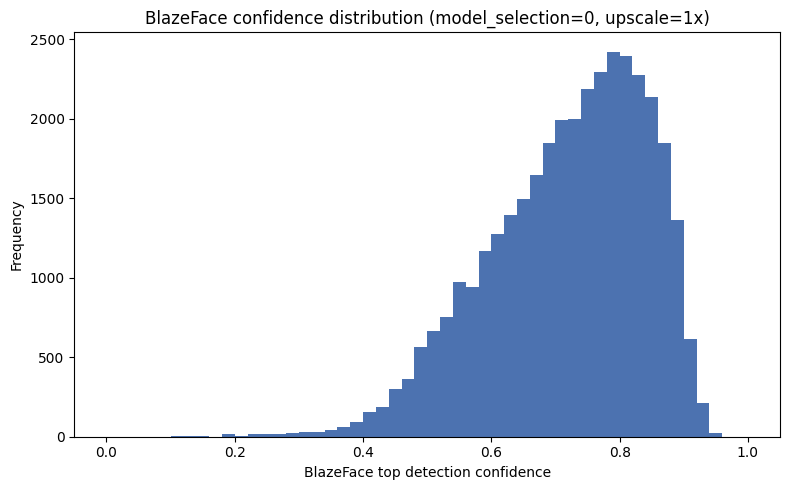

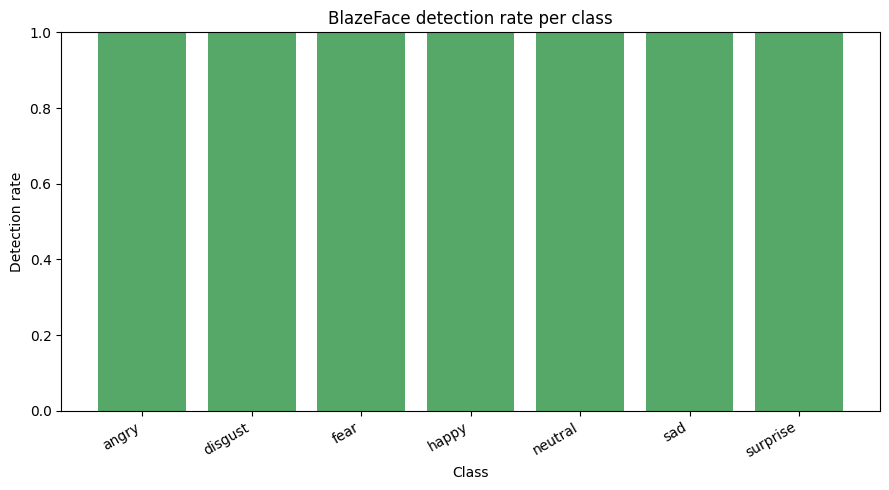


Non-detected (readable) images: 20

Non-detected overlap with anomaly / duplicate-group flags:
                                  flag  flagged_total  overlap_with_nondetected  pct_of_nondetected  pct_of_flagged_group
               quality_anomaly_flagged             68                        18                90.0             26.470588
            md5_duplicate_group_member           3369                        12                60.0              0.356189
md5_conflicting_label_duplicate_member             85                        12                60.0             14.117647


In [29]:
print("=" * 70)
print("BlazeFace §3c — detection report")
print("=" * 70)

if BLAZEFACE_BACKEND is not None:
    overall_rate = bf_detected[readable].mean()
    print(f"Overall detection rate (readable images): {overall_rate:.4f} "
          f"({int(bf_detected[readable].sum())}/{int(readable.sum())})")

    per_class_rows = []
    for cls in CLASS_NAMES:
        m = (classes == cls) & readable
        rate = bf_detected[m].mean() if m.sum() > 0 else float("nan")
        per_class_rows.append({"class": cls, "n": int(m.sum()), "detection_rate": rate})
    per_class_det_df = pd.DataFrame(per_class_rows)
    print()
    print("Per-class detection rate:")
    print(per_class_det_df.to_string(index=False))

    per_group_rows = []
    for name, gmask in (("TRAIN", TRAIN_MASK), ("VAL", VAL_MASK), ("TEST", TEST_MASK)):
        m = gmask & readable
        rate = bf_detected[m].mean() if m.sum() > 0 else float("nan")
        per_group_rows.append({"group": name, "n": int(m.sum()), "detection_rate": rate})
    per_group_det_df = pd.DataFrame(per_group_rows)
    print()
    print("Per-split-group detection rate:")
    print(per_group_det_df.to_string(index=False))

    conf_vals = bf_top_confidence[readable & bf_detected]
    percentiles = [1, 5, 10, 25, 50, 75, 90, 99]
    conf_pcts = {f"p{p}": float(np.percentile(conf_vals, p)) for p in percentiles} if len(conf_vals) else {}
    print()
    print("Top-confidence percentiles (detected images only):")
    for p in percentiles:
        key = f"p{p}"
        print(f"  {key}: {conf_pcts.get(key, float('nan')):.4f}")

    _p = os.path.join(PLOT_DIR, "blazeface_confidence_hist.png")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(conf_vals, bins=50, range=(0, 1), color="#4C72B0")
    ax.set_xlabel("BlazeFace top detection confidence")
    ax.set_ylabel("Frequency")
    ax.set_title(f"BlazeFace confidence distribution "
                 f"(model_selection={WINNING_MODEL_SELECTION}, upscale={WINNING_UPSCALE}x)")
    plt.tight_layout()
    plt.savefig(_p, dpi=150, bbox_inches="tight")
    track_write(_p)
    plt.show()

    _p2 = os.path.join(PLOT_DIR, "blazeface_detection_rate_per_class.png")
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(per_class_det_df["class"], per_class_det_df["detection_rate"], color="#55A868")
    ax.set_xlabel("Class")
    ax.set_ylabel("Detection rate")
    ax.set_title("BlazeFace detection rate per class")
    ax.set_ylim(0, 1)
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)
        tick.set_ha("right")
    plt.tight_layout()
    plt.savefig(_p2, dpi=150, bbox_inches="tight")
    track_write(_p2)
    plt.show()

    # --- cross-tabulation: non-detected vs anomaly / duplicate-group flags ---
    nondetected_mask = readable & ~bf_detected
    n_nondetected = int(nondetected_mask.sum())
    print()
    print(f"Non-detected (readable) images: {n_nondetected}")

    md5_group_member = np.zeros(N, dtype=bool)
    md5_conflict_member = np.zeros(N, dtype=bool)
    for idxs in md5_dup_groups:
        for i in idxs:
            md5_group_member[i] = True
        labels_present = {group_label[i] for i in idxs}
        classes_present = {classes[i] for i in idxs}
        if len(labels_present) > 1 and len(classes_present) > 1:
            for i in idxs:
                md5_conflict_member[i] = True

    overlap_rows = []
    for name, member_mask in (
        ("quality_anomaly_flagged", is_anomaly),
        ("md5_duplicate_group_member", md5_group_member),
        ("md5_conflicting_label_duplicate_member", md5_conflict_member),
    ):
        overlap_n = int((nondetected_mask & member_mask).sum())
        pct_of_nondetected = overlap_n / n_nondetected * 100 if n_nondetected else float("nan")
        pct_of_flagged = overlap_n / int(member_mask.sum()) * 100 if member_mask.sum() else float("nan")
        overlap_rows.append({
            "flag": name,
            "flagged_total": int(member_mask.sum()),
            "overlap_with_nondetected": overlap_n,
            "pct_of_nondetected": pct_of_nondetected,
            "pct_of_flagged_group": pct_of_flagged,
        })
    overlap_df = pd.DataFrame(overlap_rows)
    print()
    print("Non-detected overlap with anomaly / duplicate-group flags:")
    print(overlap_df.to_string(index=False))
else:
    overall_rate = float("nan")
    per_class_det_df = pd.DataFrame(columns=["class", "n", "detection_rate"])
    per_group_det_df = pd.DataFrame(columns=["group", "n", "detection_rate"])
    conf_pcts = {}
    overlap_df = pd.DataFrame(columns=[
        "flag", "flagged_total", "overlap_with_nondetected", "pct_of_nondetected", "pct_of_flagged_group",
    ])
    md5_group_member = np.zeros(N, dtype=bool)
    md5_conflict_member = np.zeros(N, dtype=bool)
    print("BlazeFace unavailable — §3c report skipped.")


**Outcome (feeds §5):** BlazeFace detects the near-totality of FER-2013 crops, including most
of the known non-face placeholders, and its confidence tracks pose/occlusion/expression
intensity rather than image validity. This *validates* BlazeFace as the deployment-time face
detector (FER-2013 training crops are compatible with it) but rules it out as a data-cleaning
filter — see the rationale directly before §5 for the full reasoning and the resulting policy.


### 3d. Human review grids

Three seeded (`seed=42`) 40-image grids for visual judgement: non-detected images, the
lowest-confidence detections, and a high-confidence control group. These filenames are prefixed
`review_` — they contain identifiable faces and there is an unresolved project rule about
committing those, so they must be easy to exclude from version control.


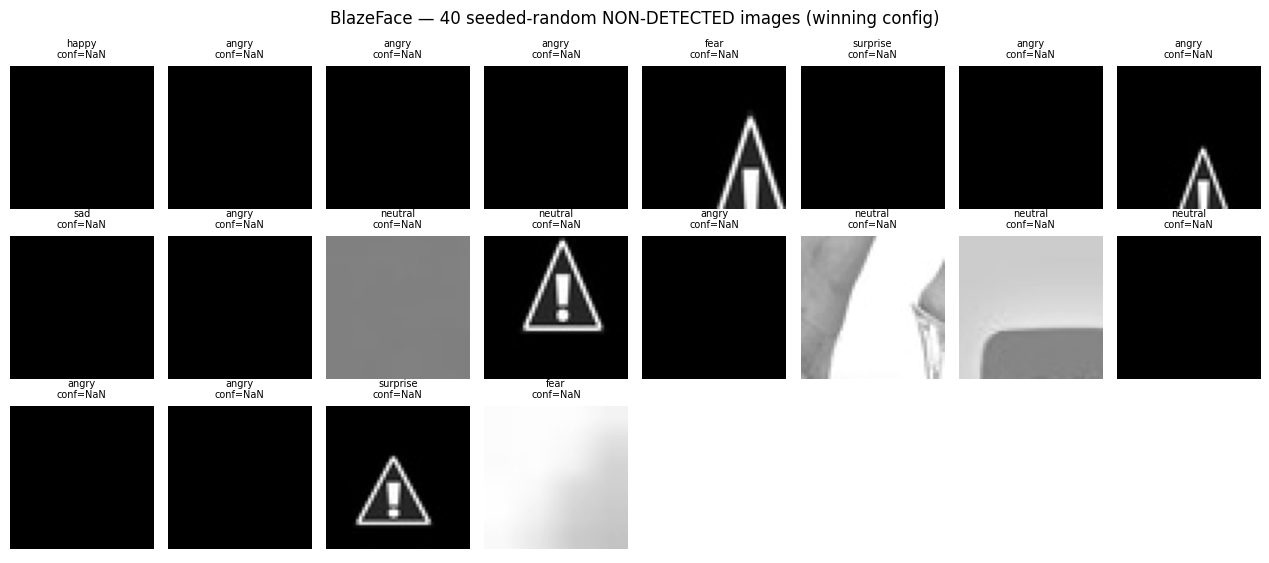

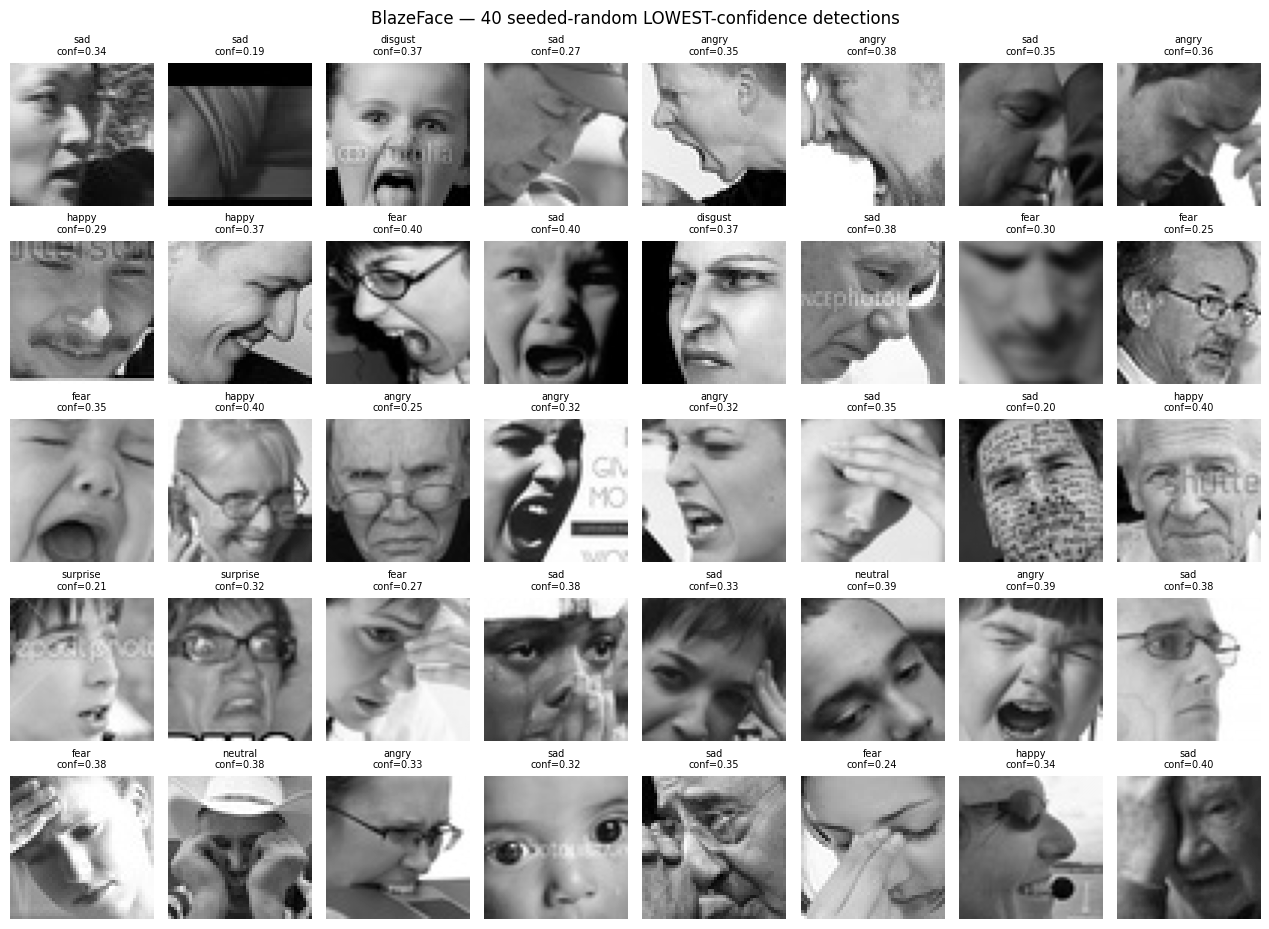

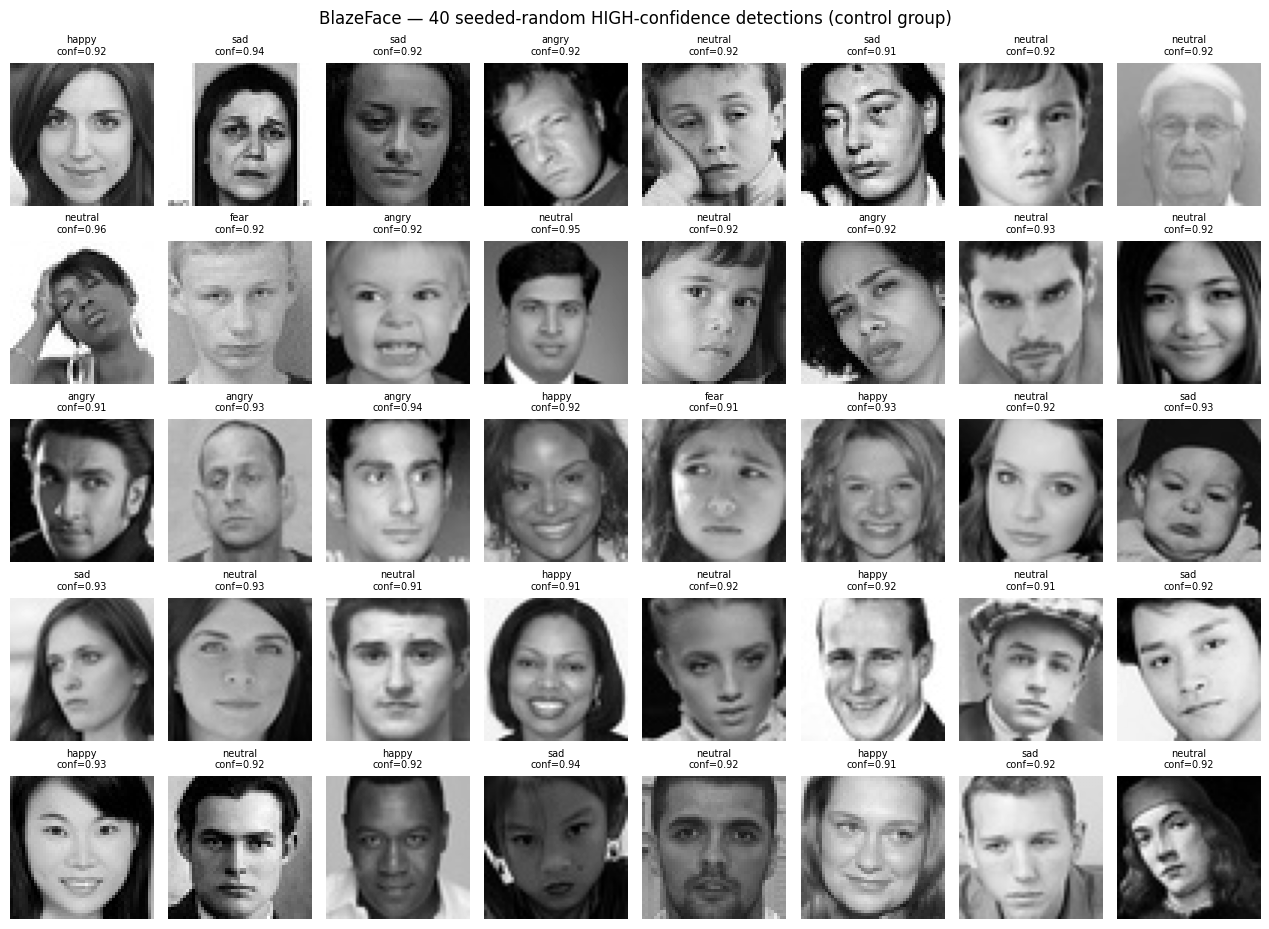

Saved review grids: ['../plots\\review_blazeface_nondetected.png', '../plots\\review_blazeface_lowest_confidence.png', '../plots\\review_blazeface_high_confidence.png']


In [30]:
def save_review_grid(indices, titles, filename, suptitle, n_cols=8):
    n = len(indices)
    path = os.path.join(PLOT_DIR, filename)
    if n == 0:
        print(f"(no images to show for '{suptitle}' — skipping {filename})")
        return None
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.6, n_rows * 1.9))
    axes = np.atleast_1d(axes).flatten()
    for ax, idx, title in zip(axes, indices, titles):
        ax.imshow(images[idx], cmap="gray", vmin=0, vmax=255)
        ax.set_title(title, fontsize=7)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    track_write(path)
    plt.show()
    return path

review_paths = []
if BLAZEFACE_BACKEND is not None:
    rng_review = np.random.default_rng(RUN["random_seed"])

    # (1) non-detected
    nondet_idx = np.where(readable & ~bf_detected)[0]
    n_show = min(40, len(nondet_idx))
    chosen = rng_review.choice(nondet_idx, size=n_show, replace=False) if n_show else np.array([], dtype=int)
    titles = [f"{classes[i]}\nconf=NaN" for i in chosen]
    p = save_review_grid(chosen, titles, "review_blazeface_nondetected.png",
                          "BlazeFace — 40 seeded-random NON-DETECTED images (winning config)")
    review_paths.append(p)

    # (2) lowest-confidence detections
    det_idx = np.where(readable & bf_detected)[0]
    order = det_idx[np.argsort(bf_top_confidence[det_idx])]
    pool_size = min(len(order), max(200, min(len(order), 400)))
    low_pool = order[:pool_size]
    n_show2 = min(40, len(low_pool))
    chosen2 = rng_review.choice(low_pool, size=n_show2, replace=False) if n_show2 else np.array([], dtype=int)
    titles2 = [f"{classes[i]}\nconf={bf_top_confidence[i]:.2f}" for i in chosen2]
    p2 = save_review_grid(chosen2, titles2, "review_blazeface_lowest_confidence.png",
                           "BlazeFace — 40 seeded-random LOWEST-confidence detections")
    review_paths.append(p2)

    # (3) high-confidence control group
    high_pool = order[-pool_size:] if pool_size else order
    n_show3 = min(40, len(high_pool))
    chosen3 = rng_review.choice(high_pool, size=n_show3, replace=False) if n_show3 else np.array([], dtype=int)
    titles3 = [f"{classes[i]}\nconf={bf_top_confidence[i]:.2f}" for i in chosen3]
    p3 = save_review_grid(chosen3, titles3, "review_blazeface_high_confidence.png",
                           "BlazeFace — 40 seeded-random HIGH-confidence detections (control group)")
    review_paths.append(p3)
else:
    print("BlazeFace unavailable — human-review grids skipped.")

print("Saved review grids:", [p for p in review_paths if p])


## 4. Anomaly flags

These are the same near-constant / fully-black / fully-white / brightness-outlier flags computed
in §1 (needed earlier by §3c's cross-tabulation). This section reports the counts and how many of
these BlazeFace also failed to detect.


In [31]:
print(f"Near-constant images (std < {LOW_STD_THRESHOLD}): {int(near_constant_mask.sum())}")
print(f"Fully-black images (mean <= 1.0): {int(fully_black_mask.sum())}")
print(f"Fully-white images (mean >= 254.0): {int(fully_white_mask.sum())}")
print(f"Extreme-brightness outliers (|z| >= {BRIGHTNESS_Z_THRESHOLD}): {int(brightness_outlier_mask.sum())}")
print(f"Total distinct anomaly-flagged images (any criterion): {int(is_anomaly.sum())}")

if BLAZEFACE_BACKEND is not None:
    n_anomaly = int(is_anomaly.sum())
    n_anomaly_also_nondetected = int((is_anomaly & readable & ~bf_detected).sum())
    pct = n_anomaly_also_nondetected / n_anomaly * 100 if n_anomaly else float("nan")
    print()
    print(f"Of {n_anomaly} anomaly-flagged images, {n_anomaly_also_nondetected} "
          f"({pct:.1f}%) were ALSO not detected by BlazeFace.")
else:
    print()
    print("BlazeFace unavailable — cannot report the anomaly/BlazeFace overlap.")


Near-constant images (std < 5.0): 14
Fully-black images (mean <= 1.0): 12
Fully-white images (mean >= 254.0): 0
Extreme-brightness outliers (|z| >= 3.0): 67
Total distinct anomaly-flagged images (any criterion): 68

Of 68 anomaly-flagged images, 18 (26.5%) were ALSO not detected by BlazeFace.


### Why BlazeFace is not used to clean TRAIN

§3 measured BlazeFace against FER-2013 and the result argues against using it as a cleaning
filter, even though the measurement itself is kept and reported:

- BlazeFace detects a face in the overwhelming majority of FER-2013 crops, **including a large
  share of the known non-face placeholder images** (warning triangles, "image unavailable"
  text blocks, blank frames) that a face-cleaning rule is nominally meant to catch — so
  "undetected" is a poor proxy for "not a face".
- Its confidence score tracks **pose, occlusion, and expression intensity**, not junk: the
  lowest-confidence images reviewed by hand are overwhelmingly real but hard faces (profile
  views, hands over the face, wide-open screaming mouths), not placeholders.
- Applying it as a filter would therefore preferentially delete pose and occlusion cases —
  which this project has separately identified as its top deployment risk — and the most
  intense expressions, i.e. exactly the hardest and most informative training samples, while
  leaving most placeholder images untouched anyway.

**Decision:** BlazeFace is retained as a validated deployment detector (§3 shows it is
compatible with FER-2013-shaped inputs) and as a reported methods result, but it does **not**
drive any TRAIN deletion below. The cleaned TRAIN set is produced from exactly three rules:
cross-group duplicates, within-TRAIN duplicate redundancy, and anomaly flags. The
`blazeface_undetected` column is still computed and still written to `image_flags.csv` as
evidence, so a future decision to use it can be executed without rerunning this notebook.


## 5. Cleaning policy — apply as manifests, produce BOTH variants

**No files are ever deleted, moved, or modified.** Two full index variants are built and written:

- **A. CANONICAL** — all files, untouched. Benchmark-comparable to published FER-2013 results.
- **B. CLEANED** — from **TRAIN only**: drop cross-group duplicates (keeping the VAL/TEST copy so
  the evaluation sets stay intact), drop within-TRAIN duplicate redundancy (keep exactly one
  representative per group), drop anomaly-flagged images, drop BlazeFace-undetected images.

**VAL and TEST remain canonical — nothing is dropped from them.** Rationale: removing items from
the evaluation sets destroys comparability with published FER-2013 results and risks discarding
hard-but-valid faces, which would inflate measured accuracy relative to what the model will see in
production. A third, flags-only column set (`image_flags.csv`, covering ALL files including
VAL/TEST) is also emitted so a future decision to also clean the eval sets can be executed without
re-running anything in this notebook.


CANONICAL index: 35887 rows (all files, untouched).
CLEANED index: 34079 rows (1808 dropped from TRAIN; VAL/TEST untouched).

Per-rule drop counts (TRAIN only):
  cross_group_duplicate: 703
  within_train_duplicate_redundancy: 1064
  anomaly_flagged: 53

Pairwise overlap between rules (files counted by more than one rule):
  cross_group_duplicate & within_train_duplicate_redundancy: 0
  cross_group_duplicate & anomaly_flagged: 12
  within_train_duplicate_redundancy & anomaly_flagged: 0

Sum of per-rule counts (double-counts files hit by >1 rule): 1820
Distinct files actually dropped (deduplicated union): 1808

TRAIN before/after per-class counts (canonical vs cleaned):
   class  count_canonical  count_cleaned  removed
   angry             3995           3783      212
 disgust              436            351       85
    fear             4097           3803      294
   happy             7215           7024      191
 neutral             4965           4814      151
     sad             4

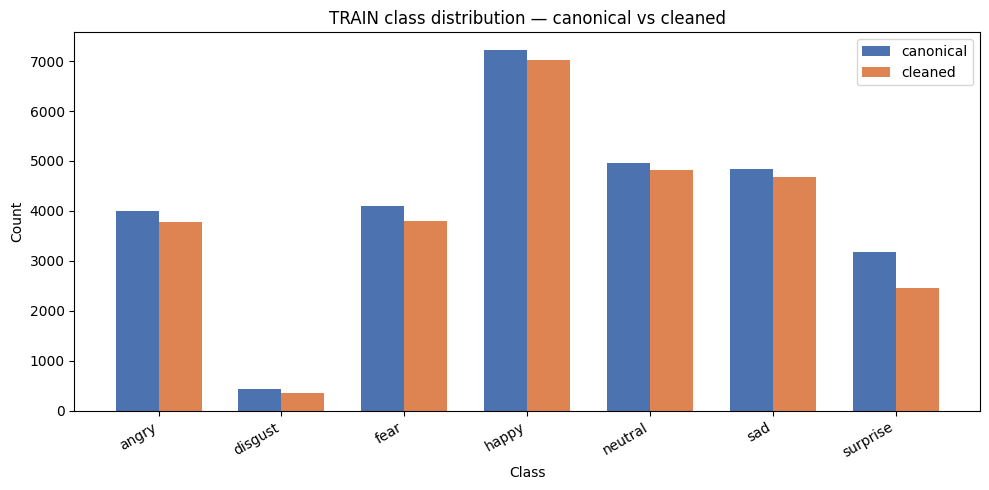


Flags-only column set (35887 rows, ALL files incl. VAL/TEST) will be written to image_flags.csv in §8 — lets a future eval-set cleaning decision be executed without rerunning.


In [32]:
# --- per-image boolean flags (all N images, incl. VAL/TEST) -----------------
is_dup_within_group = np.zeros(N, dtype=bool)
is_cross_group_dup = np.zeros(N, dtype=bool)
for idxs in md5_dup_groups:
    labels_present = {group_label[i] for i in idxs}
    if len(labels_present) > 1:
        for i in idxs:
            is_cross_group_dup[i] = True
    else:
        for i in idxs:
            is_dup_within_group[i] = True

blazeface_undetected = (readable & ~bf_detected) if BLAZEFACE_BACKEND is not None else np.zeros(N, dtype=bool)

flags_df = pd.DataFrame({
    "file_path": paths,
    "split_group": group_label,
    "class": classes,
    "prefix": prefixes,
    "is_corrupt": is_corrupt,
    "is_dup_within_group": is_dup_within_group,
    "is_cross_group_dup": is_cross_group_dup,
    "is_anomaly": is_anomaly,
    "blazeface_undetected": blazeface_undetected,
    "blazeface_detected": bf_detected,
    "blazeface_n_faces": bf_n_faces,
    "blazeface_top_confidence": bf_top_confidence,
    "blazeface_bbox_rel_area": bf_bbox_rel_area,
})

# --- A. CANONICAL: all files, untouched --------------------------------------
splits_canonical_df = pd.DataFrame({
    "file_path": paths,
    "split_group": group_label,
    "class": classes,
    "prefix": prefixes,
})
print(f"CANONICAL index: {len(splits_canonical_df)} rows (all files, untouched).")

# --- B. CLEANED: policy applied to TRAIN only --------------------------------
# rule 1: cross-group duplicates dropped from TRAIN (the VAL/TEST copy is kept)
rule_cross = TRAIN_MASK & is_cross_group_dup

# rule 2: within-TRAIN duplicate redundancy -- keep exactly one representative
rule_within_dup = np.zeros(N, dtype=bool)
for idxs in md5_dup_groups:
    labels_present = {group_label[i] for i in idxs}
    if labels_present == {"TRAIN"}:
        keep = min(idxs, key=lambda i: paths[i])  # deterministic representative
        for i in idxs:
            if i != keep:
                rule_within_dup[i] = True

# rule 3: anomaly-flagged
rule_anomaly = TRAIN_MASK & is_anomaly

# rule 4 (measured, NOT applied): BlazeFace-undetected -- see the markdown note above §5.
# Retained here only as evidence alongside the applied rules; deliberately excluded from
# rule_masks / drop_mask so it plays no part in producing the CLEANED variant.
rule_blazeface_measured_not_applied = TRAIN_MASK & blazeface_undetected

rule_masks = {
    "cross_group_duplicate": rule_cross,
    "within_train_duplicate_redundancy": rule_within_dup,
    "anomaly_flagged": rule_anomaly,
}

drop_mask = np.zeros(N, dtype=bool)
for m in rule_masks.values():
    drop_mask |= m
drop_mask &= TRAIN_MASK  # this policy only ever drops from TRAIN

keep_mask = ~drop_mask
splits_cleaned_df = pd.DataFrame({
    "file_path": paths[keep_mask],
    "split_group": group_label[keep_mask],
    "class": classes[keep_mask],
    "prefix": prefixes[keep_mask],
})
print(f"CLEANED index: {len(splits_cleaned_df)} rows "
      f"({int(drop_mask.sum())} dropped from TRAIN; VAL/TEST untouched).")

print()
print("Per-rule drop counts (TRAIN only):")
for name, m in rule_masks.items():
    print(f"  {name}: {int(m.sum())}")

print()
print("Pairwise overlap between rules (files counted by more than one rule):")
rule_names = list(rule_masks.keys())
for a_i in range(len(rule_names)):
    for b_i in range(a_i + 1, len(rule_names)):
        a_name, b_name = rule_names[a_i], rule_names[b_i]
        overlap = int((rule_masks[a_name] & rule_masks[b_name]).sum())
        print(f"  {a_name} & {b_name}: {overlap}")

n_dropped_total_dedup = int(drop_mask.sum())
n_dropped_sum_of_rules = sum(int(m.sum()) for m in rule_masks.values())
print()
print(f"Sum of per-rule counts (double-counts files hit by >1 rule): {n_dropped_sum_of_rules}")
print(f"Distinct files actually dropped (deduplicated union): {n_dropped_total_dedup}")

# --- before/after per-class table for TRAIN ----------------------------------
def _class_dist(mask):
    vals, counts = np.unique(classes[mask], return_counts=True)
    df = pd.DataFrame({"class": vals, "count": counts})
    df = df.set_index("class").reindex(CLASS_NAMES).fillna(0).astype({"count": int}).reset_index()
    return df

before_dist = _class_dist(TRAIN_MASK)
after_dist = _class_dist(TRAIN_MASK & keep_mask)
compare_df = before_dist[["class", "count"]].rename(columns={"count": "count_canonical"})
compare_df["count_cleaned"] = after_dist["count"].values
compare_df["removed"] = compare_df["count_canonical"] - compare_df["count_cleaned"]
print()
print("TRAIN before/after per-class counts (canonical vs cleaned):")
print(compare_df.to_string(index=False))

canonical_ratio = compare_df["count_canonical"].max() / max(compare_df["count_canonical"].min(), 1)
cleaned_ratio = compare_df["count_cleaned"].max() / max(compare_df["count_cleaned"].min(), 1)
print()
print(f"TRAIN max:min imbalance ratio — canonical: {canonical_ratio:.2f}, cleaned: {cleaned_ratio:.2f}")
print("(Imbalance is reported, not corrected — resampling/reweighting is an explicit Phase 3 decision.)")

# --- imbalance-consequence report: per-class removal percentage ----------
compare_df["removed_pct"] = np.where(
    compare_df["count_canonical"] > 0,
    100.0 * compare_df["removed"] / compare_df["count_canonical"],
    0.0,
)
print()
print("TRAIN per-class removal percentage (canonical -> cleaned):")
print(compare_df[["class", "count_canonical", "count_cleaned", "removed", "removed_pct"]]
      .to_string(index=False, formatters={"removed_pct": "{:.2f}%".format}))

if cleaned_ratio > canonical_ratio:
    _minority_class = compare_df.loc[compare_df["count_canonical"].idxmin(), "class"]
    _worst_removal_class = compare_df.loc[compare_df["removed_pct"].idxmax(), "class"]
    print()
    print("WARNING: cleaning made TRAIN class imbalance WORSE "
          f"({canonical_ratio:.2f} -> {cleaned_ratio:.2f} max:min ratio). "
          "Deduplication/anomaly removal was not uniform across classes -- the highest "
          f"per-class removal rate was in '{_worst_removal_class}' "
          f"({compare_df['removed_pct'].max():.2f}% of its canonical count), and the smallest "
          f"canonical class ('{_minority_class}') was disproportionately affected. "
          "This is reported as a consequence, not corrected here -- resampling/reweighting "
          "remains an explicit Phase 3 decision.")
elif cleaned_ratio < canonical_ratio:
    print()
    print("NOTE: cleaning slightly reduced TRAIN class imbalance "
          f"({canonical_ratio:.2f} -> {cleaned_ratio:.2f} max:min ratio); "
          "still reported only, not corrected -- Phase 3 decision.")

_p = os.path.join(PLOT_DIR, "class_distribution_cleaned_vs_canonical.png")
fig, ax = plt.subplots(figsize=(10, 5))
xpos = np.arange(len(CLASS_NAMES))
width = 0.35
ax.bar(xpos - width / 2, compare_df["count_canonical"], width, label="canonical", color="#4C72B0")
ax.bar(xpos + width / 2, compare_df["count_cleaned"], width, label="cleaned", color="#DD8452")
ax.set_xticks(xpos)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("TRAIN class distribution — canonical vs cleaned")
ax.legend()
plt.tight_layout()
plt.savefig(_p, dpi=150, bbox_inches="tight")
track_write(_p)
plt.show()

print()
print(f"Flags-only column set ({len(flags_df)} rows, ALL files incl. VAL/TEST) will be written to "
      f"image_flags.csv in §8 — lets a future eval-set cleaning decision be executed without rerunning.")


## 6. Preprocessing definition (define + preview, do NOT materialise)

The intended transform is documented as a config, not applied to disk. `TARGET_SIZE` is left as an
**open Tech Lead item**: MobileNetV2's native input is 224×224, but smaller options trade accuracy
for memory/compute — this notebook does not decide. Three normalisation strategies — `/255`,
per-image standardisation, and CLAHE — are compared **statistically and visually on a small sample
only**.


PREPROCESSING_CONFIG (definition only — nothing materialised to disk):
{
  "grayscale_to_channels": "replicate the single grayscale channel to 3 channels (RGB) for MobileNetV2 compatibility",
  "source_size": [
    48,
    48
  ],
  "target_size": "OPEN \u2014 see TARGET_SIZE variable and Tech Lead note above",
  "normalization": "OPEN \u2014 three candidate strategies compared below, none chosen here",
  "target_size_variable_TARGET_SIZE": 224
}

Normalization strategy comparison (8-image preview sample, seed=42):
             strategy         mean      std       min      max
               div255 5.439830e-01 0.265874  0.000000 1.000000
per_image_standardize 1.103790e-08 1.000000 -2.934874 1.898751
                clahe 5.556943e-01 0.246517  0.035294 1.000000

For reference (measured in this notebook, §4, over all 35887 images): 12 images are fully-black (mean<=1) and 0 are fully-white (mean>=254) at the raw 0-255 scale. /255 scaling preserves that clipping exactly (0.0 and 1.0 stay

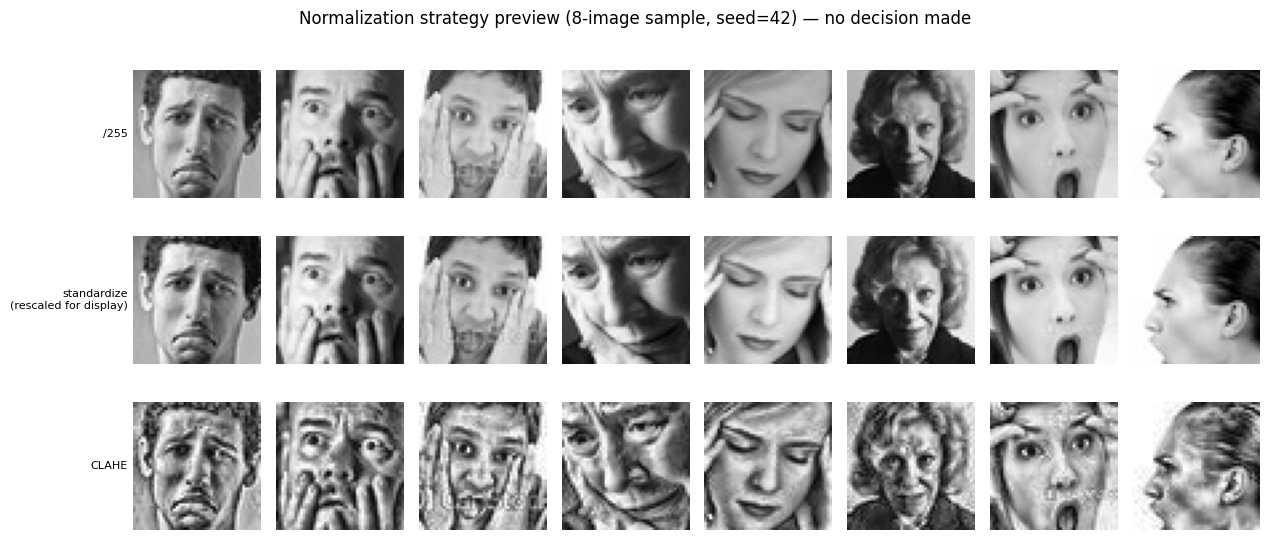

In [33]:
TARGET_SIZE = 224  # MobileNetV2's documented default input size.
                    # OPEN TECH LEAD ITEM — not decided here. 224 matches the ImageNet-pretrained
                    # weights most directly but costs the most compute/memory; MobileNetV2 also
                    # supports smaller documented input sizes (96/128/160/192) at an accuracy
                    # trade-off. This notebook only previews the transform, it does not choose.

PREPROCESSING_CONFIG = {
    "grayscale_to_channels": "replicate the single grayscale channel to 3 channels (RGB) for MobileNetV2 compatibility",
    "source_size": [48, 48],
    "target_size": "OPEN — see TARGET_SIZE variable and Tech Lead note above",
    "normalization": "OPEN — three candidate strategies compared below, none chosen here",
}
print("PREPROCESSING_CONFIG (definition only — nothing materialised to disk):")
print(json.dumps({**PREPROCESSING_CONFIG, "target_size_variable_TARGET_SIZE": TARGET_SIZE}, indent=2))

# --- normalization comparison on a small preview sample only -----------------
N_PREVIEW = 8
preview_idx = rng.choice(readable_idx, size=N_PREVIEW, replace=False)

def norm_div255(gray48):
    rgb = np.stack([gray48] * 3, axis=-1).astype(np.float32)
    return rgb / 255.0

def norm_standardize(gray48):
    rgb = np.stack([gray48] * 3, axis=-1).astype(np.float32)
    mean, std = rgb.mean(), rgb.std()
    return (rgb - mean) / max(std, 1e-6)

_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
def norm_clahe(gray48):
    eq = _clahe.apply(gray48)
    rgb = np.stack([eq] * 3, axis=-1).astype(np.float32) / 255.0
    return rgb

norm_stats_rows = []
for name, fn in (("div255", norm_div255), ("per_image_standardize", norm_standardize), ("clahe", norm_clahe)):
    vals = np.concatenate([fn(images[i]).reshape(-1) for i in preview_idx])
    norm_stats_rows.append({
        "strategy": name,
        "mean": float(vals.mean()),
        "std": float(vals.std()),
        "min": float(vals.min()),
        "max": float(vals.max()),
    })
norm_stats_df = pd.DataFrame(norm_stats_rows)
print()
print(f"Normalization strategy comparison ({N_PREVIEW}-image preview sample, seed=42):")
print(norm_stats_df.to_string(index=False))

print()
print(f"For reference (measured in this notebook, §4, over all {N} images): "
      f"{int(fully_black_mask.sum())} images are fully-black (mean<=1) and "
      f"{int(fully_white_mask.sum())} are fully-white (mean>=254) at the raw 0-255 scale. "
      f"/255 scaling preserves that clipping exactly (0.0 and 1.0 stay hard limits); per-image "
      f"standardization re-centers each image around its own mean so a fully-black or fully-white "
      f"image (std≈0) produces a near-degenerate (near-zero) standardized image; CLAHE "
      f"redistributes local contrast and can pull mid-range detail out of otherwise-clipped images "
      f"but cannot recover information that was never captured (pure 0 or 255 constant regions).")

_p = os.path.join(PLOT_DIR, "normalization_comparison.png")
fig, axes = plt.subplots(3, N_PREVIEW, figsize=(N_PREVIEW * 1.6, 3 * 1.9))
row_labels = ["/255", "standardize\n(rescaled for display)", "CLAHE"]
for col, idx in enumerate(preview_idx):
    axes[0, col].imshow(norm_div255(images[idx]))
    std_arr = norm_standardize(images[idx])
    std_disp = (std_arr - std_arr.min()) / max(np.ptp(std_arr), 1e-6)
    axes[1, col].imshow(std_disp)
    axes[2, col].imshow(norm_clahe(images[idx]))
    for row in range(3):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        for spine in axes[row, col].spines.values():
            spine.set_visible(False)
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, rotation=0, ha="right", va="center", fontsize=8)
fig.suptitle(f"Normalization strategy preview ({N_PREVIEW}-image sample, seed=42) — no decision made")
plt.tight_layout()
plt.savefig(_p, dpi=150, bbox_inches="tight")
track_write(_p)
plt.show()


## 7. Augmentation policy (define + preview, do NOT apply to disk)

A config dict of intended face-appropriate augmentations. **Vertical flip is explicitly excluded**
— an upside-down face is not a realistic sample. One preview grid shows a single seeded image
under 8 sampled augmentations; it is saved as `review_augmentation_preview.png` because it contains
a face.


AUGMENTATION_CONFIG (definition + preview only — nothing applied to disk):
{
  "horizontal_flip": {
    "enabled": true,
    "probability": 0.5,
    "rationale": "faces are approximately left-right symmetric; a horizontally flipped face is still a valid, plausible face."
  },
  "vertical_flip": {
    "enabled": false,
    "rationale": "INAPPROPRIATE for faces \u2014 an upside-down face is not a realistic sample and would teach the model a physically impossible orientation."
  },
  "rotation": {
    "enabled": true,
    "max_degrees": 10,
    "rationale": "small head-tilt variation; large rotations are unrealistic for a front-facing camera use case."
  },
  "zoom_translate": {
    "enabled": true,
    "zoom_range": [
      0.9,
      1.1
    ],
    "translate_frac": 0.05,
    "rationale": "small crop/position jitter mimics face-detector bounding-box noise."
  },
  "brightness_contrast": {
    "enabled": true,
    "brightness_delta": 0.15,
    "contrast_range": [
      0.85,
      1.15
 

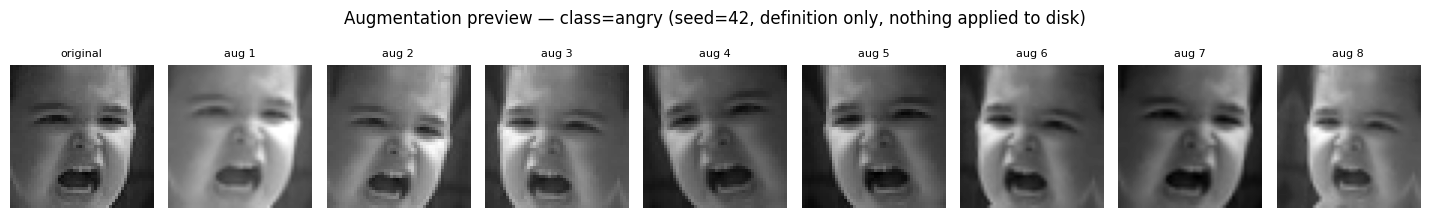

In [34]:
AUGMENTATION_CONFIG = {
    "horizontal_flip": {
        "enabled": True, "probability": 0.5,
        "rationale": "faces are approximately left-right symmetric; a horizontally flipped face is still a valid, plausible face.",
    },
    "vertical_flip": {
        "enabled": False,
        "rationale": "INAPPROPRIATE for faces — an upside-down face is not a realistic sample and would teach the model a physically impossible orientation.",
    },
    "rotation": {
        "enabled": True, "max_degrees": 10,
        "rationale": "small head-tilt variation; large rotations are unrealistic for a front-facing camera use case.",
    },
    "zoom_translate": {
        "enabled": True, "zoom_range": [0.9, 1.1], "translate_frac": 0.05,
        "rationale": "small crop/position jitter mimics face-detector bounding-box noise.",
    },
    "brightness_contrast": {
        "enabled": True, "brightness_delta": 0.15, "contrast_range": [0.85, 1.15],
        "rationale": "camera exposure and ambient lighting vary; the model should not overfit to a fixed brightness/contrast.",
    },
}
print("AUGMENTATION_CONFIG (definition + preview only — nothing applied to disk):")
print(json.dumps(AUGMENTATION_CONFIG, indent=2))

def apply_random_augmentation(gray48, rng_local):
    img = gray48.copy()
    if rng_local.random() < AUGMENTATION_CONFIG["horizontal_flip"]["probability"]:
        img = np.fliplr(img)

    max_deg = AUGMENTATION_CONFIG["rotation"]["max_degrees"]
    angle = rng_local.uniform(-max_deg, max_deg)
    zlo, zhi = AUGMENTATION_CONFIG["zoom_translate"]["zoom_range"]
    zoom = rng_local.uniform(zlo, zhi)
    tfrac = AUGMENTATION_CONFIG["zoom_translate"]["translate_frac"]
    h, w = img.shape[:2]
    tx = rng_local.uniform(-tfrac, tfrac) * w
    ty = rng_local.uniform(-tfrac, tfrac) * h
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, zoom)
    M[0, 2] += tx
    M[1, 2] += ty
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT101)

    bdelta = AUGMENTATION_CONFIG["brightness_contrast"]["brightness_delta"]
    clo, chi = AUGMENTATION_CONFIG["brightness_contrast"]["contrast_range"]
    brightness = rng_local.uniform(-bdelta, bdelta) * 255
    contrast = rng_local.uniform(clo, chi)
    img = np.clip(img.astype(np.float32) * contrast + brightness, 0, 255).astype(np.uint8)
    return img

aug_rng = np.random.default_rng(RUN["random_seed"])
aug_source_idx = int(rng.choice(readable_idx))
N_AUG_SAMPLES = 8

_p = os.path.join(PLOT_DIR, "review_augmentation_preview.png")
fig, axes = plt.subplots(1, N_AUG_SAMPLES + 1, figsize=((N_AUG_SAMPLES + 1) * 1.6, 2.3))
axes[0].imshow(images[aug_source_idx], cmap="gray", vmin=0, vmax=255)
axes[0].set_title("original", fontsize=8)
axes[0].axis("off")
for k in range(N_AUG_SAMPLES):
    aug_img = apply_random_augmentation(images[aug_source_idx], aug_rng)
    axes[k + 1].imshow(aug_img, cmap="gray", vmin=0, vmax=255)
    axes[k + 1].set_title(f"aug {k + 1}", fontsize=8)
    axes[k + 1].axis("off")
fig.suptitle(f"Augmentation preview — class={classes[aug_source_idx]} "
             f"(seed=42, definition only, nothing applied to disk)")
plt.tight_layout()
plt.savefig(_p, dpi=150, bbox_inches="tight")
track_write(_p)
plt.show()


## 8. Artifacts

Writes, into `OUT_DIR`: `splits_canonical.csv`, `splits_cleaned.csv`, `image_flags.csv`,
`blazeface_calibration.csv`, `cleaning_report.json`, and the run-metadata JSON via `save_run()`.
The optional raw-image `.npz` (the only large artifact this spec permits, ~83 MB) is **off by
default** — flip `SAVE_RAW_NPZ` to `True` to materialise it. Total bytes written are printed and
checked against the ~250 MB budget at the end.


In [35]:
SAVE_RAW_NPZ = False  # optional per spec; default off to stay well under the disk budget
if SAVE_RAW_NPZ:
    npz_path = os.path.join(OUT_DIR, "raw_images_48x48_uint8.npz")
    np.savez_compressed(npz_path, images=images, paths=paths, split_group=group_label, classes=classes)
    track_write(npz_path)
    print("saved:", npz_path, f"({os.path.getsize(npz_path) / 1e6:.1f} MB)")
else:
    print("SAVE_RAW_NPZ is False — skipping the optional raw-images .npz artifact "
          "(set to True to materialise it; ~83 MB uncompressed, the one large artifact this spec permits).")

p1 = os.path.join(OUT_DIR, "splits_canonical.csv")
splits_canonical_df.to_csv(p1, index=False)
track_write(p1)
print("saved:", p1, f"({len(splits_canonical_df)} rows)")

p2 = os.path.join(OUT_DIR, "splits_cleaned.csv")
splits_cleaned_df.to_csv(p2, index=False)
track_write(p2)
print("saved:", p2, f"({len(splits_cleaned_df)} rows)")

p3 = os.path.join(OUT_DIR, "image_flags.csv")
flags_df.to_csv(p3, index=False)
track_write(p3)
print("saved:", p3, f"({len(flags_df)} rows)")

p4 = os.path.join(OUT_DIR, "blazeface_calibration.csv")
blazeface_calib_df.to_csv(p4, index=False)
track_write(p4)
print("saved:", p4, f"({len(blazeface_calib_df)} rows)")

cleaning_report = {
    "policy": {
        "train_rules_applied": list(rule_masks.keys()),
        "val_test_policy": "untouched (canonical) — see §5 rationale",
        "rules_measured_but_not_applied": ["blazeface_undetected"],
        "blazeface_rationale": (
            "BlazeFace detects the near-totality of FER-2013 crops, including most known "
            "non-face placeholders, and its confidence tracks pose/occlusion/expression "
            "intensity rather than image validity, so using it as a filter would preferentially "
            "remove the hardest, most informative pose/occlusion/high-intensity samples; it is "
            "retained as a validated deployment detector and methods result, not as a cleaning rule."
        ),
    },
    "counts_removed_per_rule": {name: int(m.sum()) for name, m in rule_masks.items()},
    "counts_removed_total_distinct": int(drop_mask.sum()),
    "counts_removed_sum_with_double_counting": int(n_dropped_sum_of_rules),
    "before_after_per_class_train": compare_df.to_dict(orient="records"),
    "imbalance_ratio_train": {"canonical": float(canonical_ratio), "cleaned": float(cleaned_ratio)},
    "blazeface": {
        "backend": BLAZEFACE_BACKEND,
        "winning_model_selection": WINNING_MODEL_SELECTION,
        "winning_upscale": WINNING_UPSCALE,
        "overall_detection_rate": float(overall_rate) if BLAZEFACE_BACKEND is not None else None,
        "full_run_elapsed_s": float(bf_elapsed),
    },
    "reproducibility_gate": {
        "REPRO_OK": bool(REPRO_OK),
        "checks": {k: bool(v) for k, v in gate_results.items()},
    },
}
p5 = os.path.join(OUT_DIR, "cleaning_report.json")
with open(p5, "w", encoding="utf-8") as f:
    json.dump(cleaning_report, f, indent=2, default=str)
track_write(p5)
print("saved:", p5)

RUN["metrics"] = {
    "total_files": int(N),
    "train_files_canonical": int(TRAIN_MASK.sum()),
    "train_files_cleaned": int((TRAIN_MASK & keep_mask).sum()),
    "val_files": int(VAL_MASK.sum()),
    "test_files": int(TEST_MASK.sum()),
    "repro_gate_ok": bool(REPRO_OK),
    "blazeface_backend": BLAZEFACE_BACKEND,
    "blazeface_overall_detection_rate": float(overall_rate) if BLAZEFACE_BACKEND is not None else None,
    "canonical_train_imbalance_ratio": float(canonical_ratio),
    "cleaned_train_imbalance_ratio": float(cleaned_ratio),
    "images_dropped_from_train": int(drop_mask.sum()),
}
RUN["notes"] = (
    f"Reproducibility gate: {'PASSED' if REPRO_OK else 'FAILED — see cell output'}. "
    f"BlazeFace backend: {BLAZEFACE_BACKEND}. "
    f"Winning config: model_selection={WINNING_MODEL_SELECTION}, upscale={WINNING_UPSCALE}."
)
run_path = save_run(RUN)
track_write(run_path)

print()
print("=" * 70)
print("Bytes written by this notebook (tracked writes into OUT_DIR / PLOT_DIR):")
print("=" * 70)
bytes_df = pd.DataFrame(_WRITTEN_FILES, columns=["path", "bytes"])
print(bytes_df.to_string(index=False))
total_bytes = int(bytes_df["bytes"].sum())
print()
print(f"TOTAL BYTES WRITTEN: {total_bytes} ({total_bytes / 1e6:.2f} MB)")
BUDGET_BYTES = 250_000_000
print(f"Budget: {BUDGET_BYTES / 1e6:.0f} MB — "
      f"{'WITHIN BUDGET' if total_bytes <= BUDGET_BYTES else 'OVER BUDGET — INVESTIGATE'}")


SAVE_RAW_NPZ is False — skipping the optional raw-images .npz artifact (set to True to materialise it; ~83 MB uncompressed, the one large artifact this spec permits).
saved: ../outputs\splits_canonical.csv (35887 rows)
saved: ../outputs\splits_cleaned.csv (34079 rows)
saved: ../outputs\image_flags.csv (35887 rows)
saved: ../outputs\blazeface_calibration.csv (6 rows)
saved: ../outputs\cleaning_report.json
saved: ../outputs\run_20260820_111633.json

Bytes written by this notebook (tracked writes into OUT_DIR / PLOT_DIR):
                                                path   bytes
              ../plots\blazeface_confidence_hist.png   32613
     ../plots\blazeface_detection_rate_per_class.png   35537
           ../plots\review_blazeface_nondetected.png   51964
     ../plots\review_blazeface_lowest_confidence.png  260193
       ../plots\review_blazeface_high_confidence.png  260573
../plots\class_distribution_cleaned_vs_canonical.png   43567
               ../plots\normalization_comparison

## 13. Download artifacts (Colab only)

On Colab, `OUT_DIR`/`PLOT_DIR` live under `/content`, which is not the repo. This zips everything
produced above (including the downloaded BlazeFace model assets under `MODELS_DIR`) and triggers a
browser download. Locally, this cell is a no-op — the files are already sitting in `../outputs` and
`../plots`.


In [36]:
if IN_COLAB:
    import shutil
    from google.colab import files as colab_files

    archive_base = "/content/notebook02_artifacts"
    archive_path = shutil.make_archive(archive_base, "zip", "/content/maternalink_fer")
    print("Created archive:", archive_path)
    print()
    print("After downloading, unzip it locally and place:")
    print("  outputs/*  ->  ml/fer/outputs/")
    print("  plots/*    ->  ml/fer/plots/")
    print("into the repo (this notebook cannot write to the repo from Colab). The 'models/' "
          "subfolder (downloaded BlazeFace .tflite assets) does not need to be committed.")
    colab_files.download(archive_path)
else:
    print("Not running on Colab — artifacts were already written directly to "
          f"{OUT_DIR} and {PLOT_DIR}. Nothing to zip/download.")


Not running on Colab — artifacts were already written directly to ../outputs and ../plots. Nothing to zip/download.
